<a href="https://colab.research.google.com/github/zenku663-svg/student-performance-pluto-academy/blob/main/StudentPerformance_Analysis_Project02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('StudentsPerformance.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(1000, 8)
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

print("=== Q1: Parental Education vs Average Total Score ===")
print(df.groupby('parental level of education')['total_score'].mean().sort_values(ascending=False))

print("\n=== Q2: Test Prep Course vs Average Scores ===")
print(df.groupby('test preparation course')[['math score','reading score','writing score']].mean())

print("\n=== Q3: Correlation between Scores ===")
print(df[['math score','reading score','writing score']].corr())

print("\n=== Q4: Gender vs Average Scores ===")
print(df.groupby('gender')[['math score','reading score','writing score']].mean())

print("\n=== Q5: Total Score Distribution ===")
print(df['total_score'].describe())

=== Q1: Parental Education vs Average Total Score ===
parental level of education
master's degree       220.796610
bachelor's degree     215.771186
associate's degree    208.707207
some college          205.429204
some high school      195.324022
high school           189.290816
Name: total_score, dtype: float64

=== Q2: Test Prep Course vs Average Scores ===
                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673

=== Q3: Correlation between Scores ===
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000

=== Q4: Gender vs Average Scores ===
        math score  reading score  writing score
gender                 

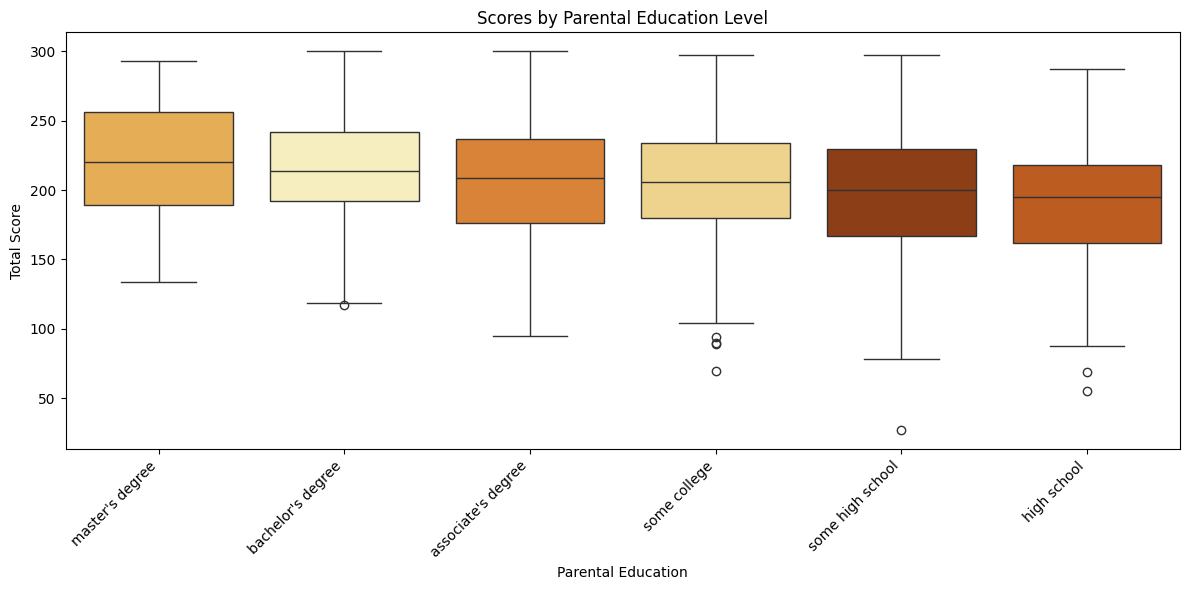

<Figure size 1000x600 with 0 Axes>

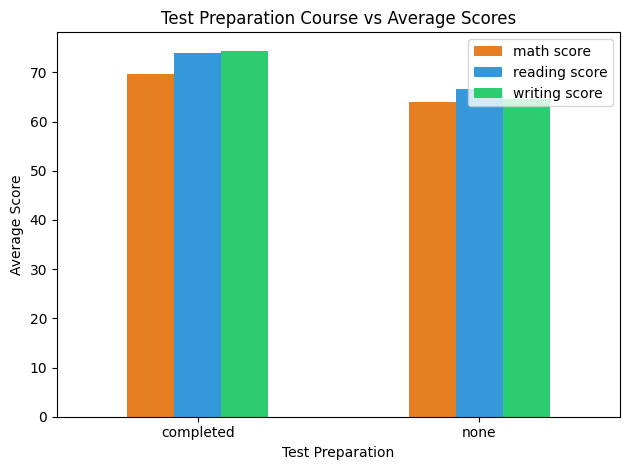

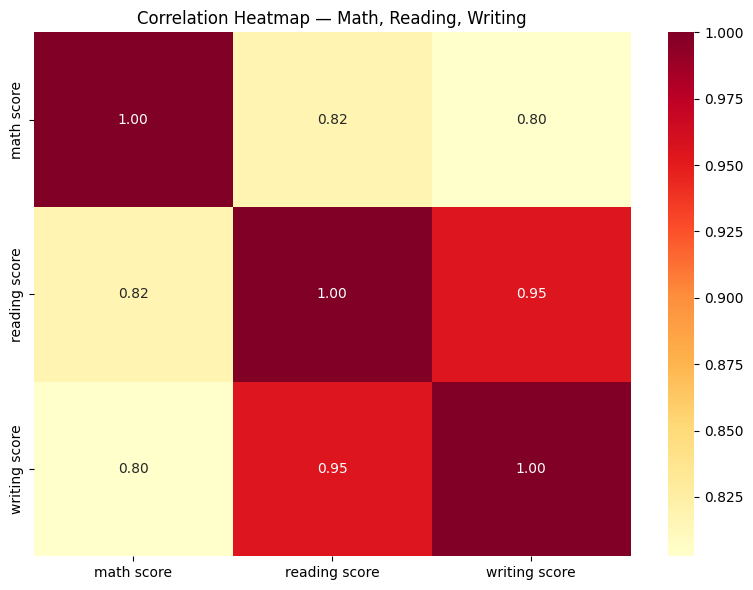

<Figure size 1000x600 with 0 Axes>

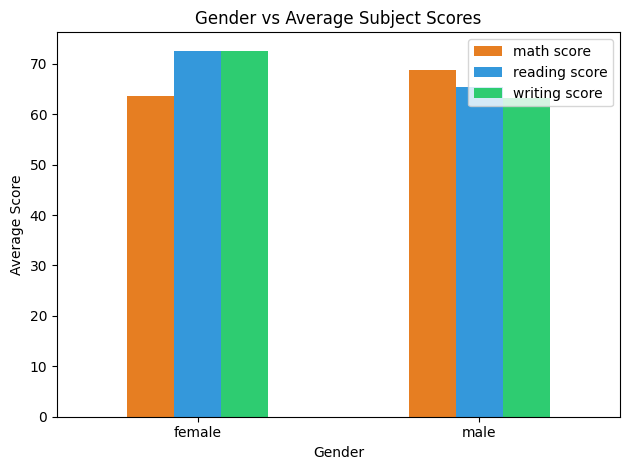

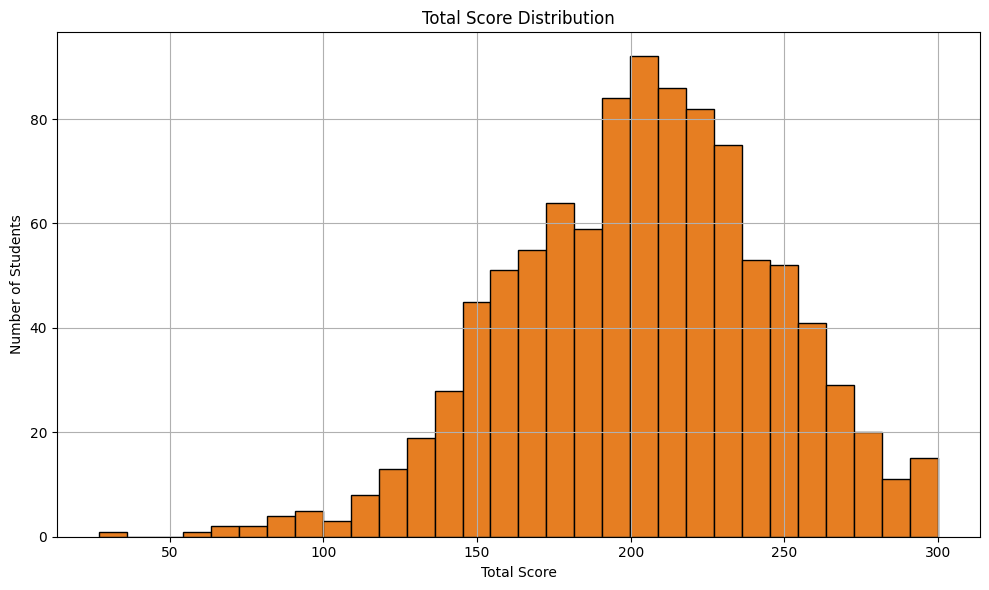

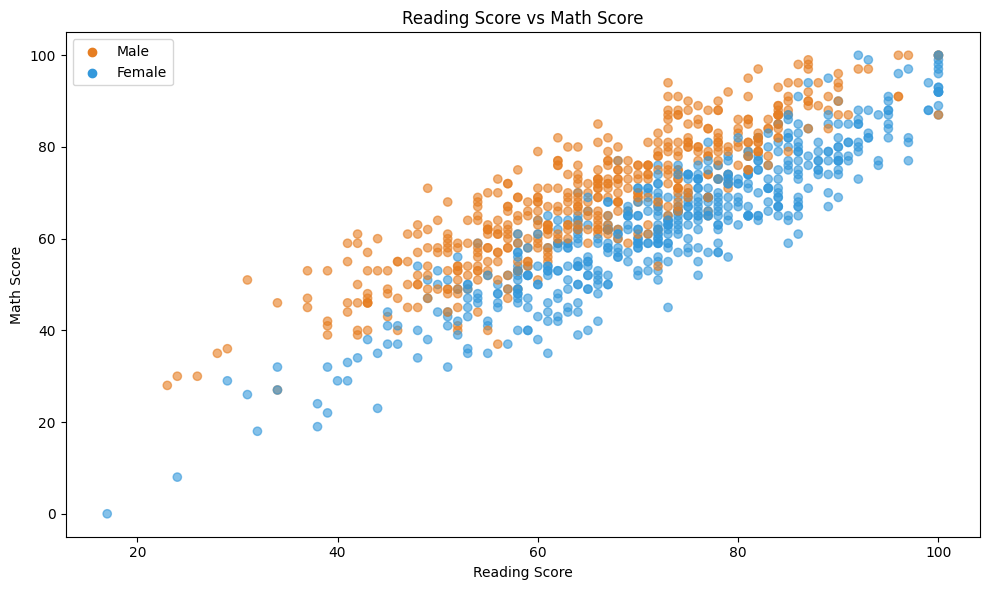

All 6 charts done!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1
plt.figure(figsize=(12,6))
order = df.groupby('parental level of education')['total_score'].mean().sort_values(ascending=False).index
sns.boxplot(x='parental level of education', y='total_score', hue='parental level of education', data=df, order=order, palette='YlOrBr', legend=False)
plt.title('Scores by Parental Education Level')
plt.xlabel('Parental Education')
plt.ylabel('Total Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_parental.png')
plt.show()

# Chart 2
plt.figure(figsize=(10,6))
df.groupby('test preparation course')[['math score','reading score','writing score']].mean().plot(kind='bar', color=['#E67E22','#3498DB','#2ECC71'])
plt.title('Test Preparation Course vs Average Scores')
plt.xlabel('Test Preparation')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_testprep.png')
plt.show()

# Chart 3
plt.figure(figsize=(8,6))
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Correlation Heatmap — Math, Reading, Writing')
plt.tight_layout()
plt.savefig('chart3_heatmap.png')
plt.show()

# Chart 4
plt.figure(figsize=(10,6))
df.groupby('gender')[['math score','reading score','writing score']].mean().plot(kind='bar', color=['#E67E22','#3498DB','#2ECC71'])
plt.title('Gender vs Average Subject Scores')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_gender.png')
plt.show()

# Chart 5
plt.figure(figsize=(10,6))
df['total_score'].hist(bins=30, color='#E67E22', edgecolor='black')
plt.title('Total Score Distribution')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('chart5_histogram.png')
plt.show()

# Chart 6
plt.figure(figsize=(10,6))
colors = ['#E67E22' if g == 'male' else '#3498DB' for g in df['gender']]
plt.scatter(df['reading score'], df['math score'], c=colors, alpha=0.6)
plt.title('Reading Score vs Math Score')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.legend(handles=[plt.scatter([],[],color='#E67E22',label='Male'), plt.scatter([],[],color='#3498DB',label='Female')])
plt.tight_layout()
plt.savefig('chart6_scatter.png')
plt.show()

print("All 6 charts done!")

In [10]:
at_risk = df[(df['math score'] < 50) |
             (df['reading score'] < 50) |
             (df['writing score'] < 50)]

print(f"Total at-risk students: {len(at_risk)} out of {len(df)}")
print(f"At-risk percentage: {len(at_risk)/len(df)*100:.1f}%")

print("\n=== At-Risk by Gender ===")
print(at_risk['gender'].value_counts())

print("\n=== At-Risk by Parental Education ===")
print(at_risk['parental level of education'].value_counts())

print("\n=== At-Risk by Test Prep ===")
print(at_risk['test preparation course'].value_counts())

print("\n=== At-Risk by Lunch Type ===")
print(at_risk['lunch'].value_counts())

Total at-risk students: 188 out of 1000
At-risk percentage: 18.8%

=== At-Risk by Gender ===
gender
male      99
female    89
Name: count, dtype: int64

=== At-Risk by Parental Education ===
parental level of education
high school           49
some high school      46
some college          38
associate's degree    33
bachelor's degree     16
master's degree        6
Name: count, dtype: int64

=== At-Risk by Test Prep ===
test preparation course
none         152
completed     36
Name: count, dtype: int64

=== At-Risk by Lunch Type ===
lunch
free/reduced    111
standard         77
Name: count, dtype: int64


In [11]:
print("""
PRINCIPAL'S REPORT — Student Performance Analysis
==================================================

EXECUTIVE SUMMARY:
Analysis of 1000 student records reveals that parental education,
test preparation, and lunch type are the strongest predictors of
academic performance. 188 students (18.8%) are currently at-risk
and require immediate intervention.

KEY FINDINGS:
1. Students with master's degree parents score 220 avg vs 189
   for high school parents — a 31 point difference.

2. Students who completed test prep scored 5-10 points higher
   in every subject compared to those who did not.

3. Reading and writing scores have 95% correlation — students
   strong in one are almost always strong in the other.

4. Males score higher in math (68.7 vs 63.6) while females
   score higher in reading (72.6 vs 65.5) and writing (72.5 vs 63.3).

5. 81% of at-risk students did NOT complete test preparation
   course — strongest single predictor of being at-risk.

RECOMMENDATIONS:
1. Make test preparation courses MANDATORY for all students —
   it clearly improves scores across all subjects.

2. Provide free/subsidized lunch to all students — 59% of
   at-risk students have free/reduced lunch showing food
   insecurity impacts academic performance.

3. Create parent education workshops — students with higher
   educated parents perform significantly better, suggesting
   home support matters. School should bridge this gap.
""")


PRINCIPAL'S REPORT — Student Performance Analysis

EXECUTIVE SUMMARY:
Analysis of 1000 student records reveals that parental education,
test preparation, and lunch type are the strongest predictors of
academic performance. 188 students (18.8%) are currently at-risk
and require immediate intervention.

KEY FINDINGS:
1. Students with master's degree parents score 220 avg vs 189
   for high school parents — a 31 point difference.

2. Students who completed test prep scored 5-10 points higher
   in every subject compared to those who did not.

3. Reading and writing scores have 95% correlation — students
   strong in one are almost always strong in the other.

4. Males score higher in math (68.7 vs 63.6) while females
   score higher in reading (72.6 vs 65.5) and writing (72.5 vs 63.3).

5. 81% of at-risk students did NOT complete test preparation
   course — strongest single predictor of being at-risk.

RECOMMENDATIONS:
1. Make test preparation courses MANDATORY for all students —
   it 